##Estadistica Aplicada

Pronostico

Bryan Alejandro Estrada Rodriguez 1844554

Grupo 42

In [1]:
# librerias Basicas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [27]:
# Especializadas
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_predict
from statsmodels.tsa.arima.model import ARIMA


#Tamaño de graficas
plt.rcParams["figure.figsize"]= (10,6)
plt.rcParams["xtick.labelsize"]= 12
plt.rcParams["ytick.labelsize"]= 12
plt.rcParams["axes.labelsize"]= 12

import pmdarima as pm

In [8]:
indicador = pd.read_csv("Indicadores.csv")
indicador["Periodos"] = pd.to_datetime(indicador["Periodos"], format="%Y/%m")
indicador = indicador.set_index("Periodos")
indicador.head()

,IMCMI_SA
Periodos,
2000-01-01,69.592772
2000-02-01,69.884806
2000-03-01,70.017659
2000-04-01,70.403639
2000-05-01,71.107793



##1.-

El período de tiempo óptimo para realizar un pronóstico del indicador Mensual del Consumo Privado IMCP depende de varios factores, incluyendo la disponibilidad de datos históricos, la estacionalidad de la serie temporal y la volatilidad de la variable en cuestión. Idealmente, el período de tiempo elegido debería ser lo suficientemente largo como para capturar patrones estacionales y tendencias a largo plazo, pero no tan largo que los datos se vuelvan obsoletos o irrelevantes. Y al observar la grafica que nos muestra el Banco de Información podemos ver caidas muy notorias en los años 2010 y 2020, por lo que creemos que esto seria un buen factor que pueda pronosticar nuestro indicador. Es por eso que tomamos desde el 2000 ya que existe una decada entre cada evento que pueda ser bueno analizar.

##2.-

In [6]:
indicador.dtypes

Periodos     object
IMCMI_SA    float64
dtype: object

In [9]:
indicador['IMCMI_SA'].isnull().sum()

0

##3.-


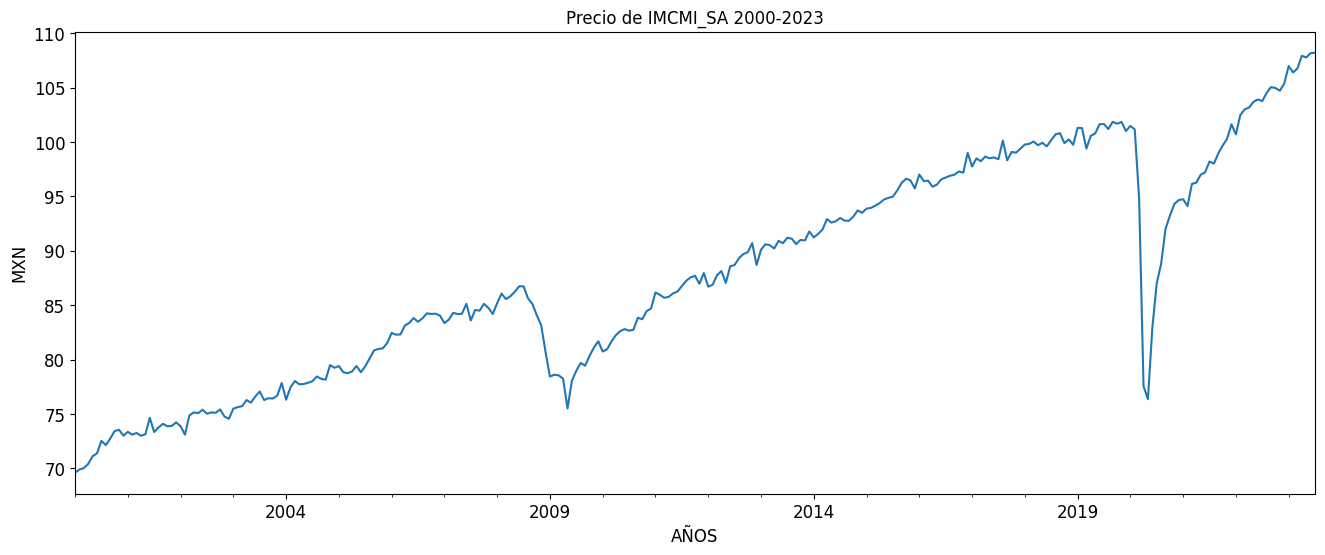

In [11]:
indicador['IMCMI_SA'].plot(figsize=(16,6))
plt.title('Precio de IMCMI_SA 2000-2023')
plt.ylabel('MXN')
plt.xlabel('AÑOS');

##4.-

a)

In [12]:
prueba_adf = adfuller(indicador['IMCMI_SA'])
pvalue = prueba_adf[1]
pvalue.round(2)

0.71

Ya que

pvalue = 0.71 >= 0.05 = Alfa

No rechazamos H0, el indicador mensual de consumo es una serie no estacionaria

b)

Por lo que aplicamos PRIMERAS DIFERENCIAS

In [13]:
indicador['IMCMI_SA.diff'] = indicador['IMCMI_SA'].diff()

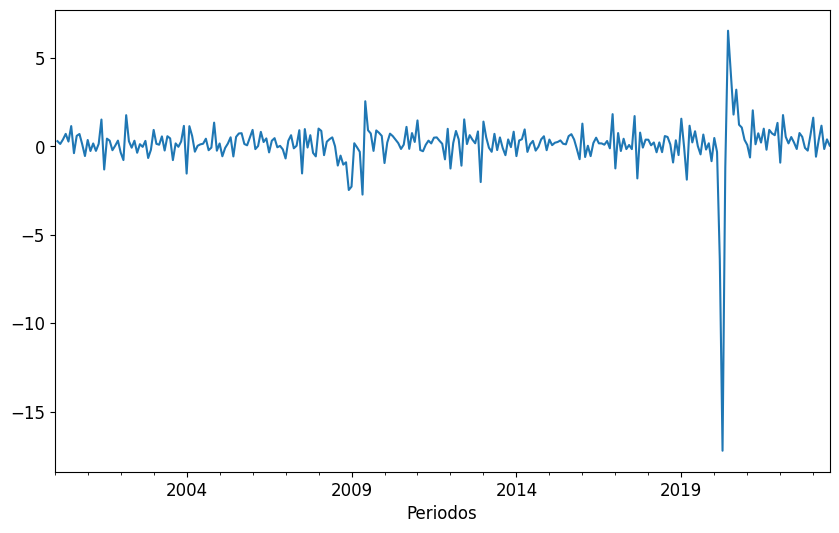

In [15]:
indicador['IMCMI_SA.diff'].plot();

In [16]:
prueba_adf1 = adfuller(indicador['IMCMI_SA.diff'].dropna())
pvalue1= prueba_adf1[1]
pvalue1.round(2)

0.0

Rechazamos H0, significa que las primeras diferencias del indicador mensual de consumo son una serie estacionaria

* IMCMI integrada I(1) = ARIMA (p,q,q)
* 1ras diferencias de IMCMI I(0) = ARIMA (p,0,q)

d)

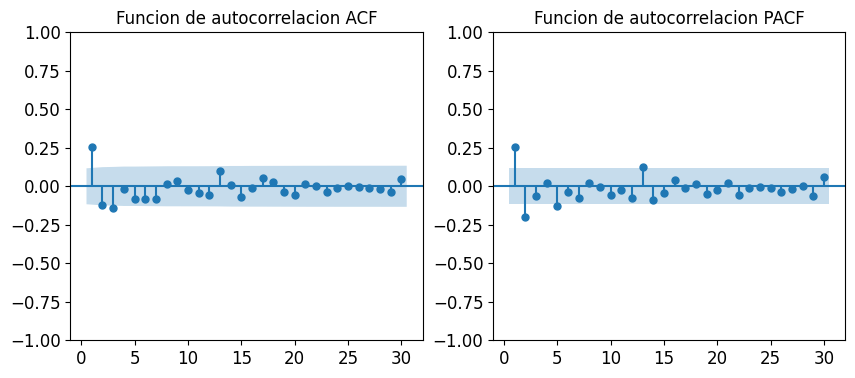

In [21]:
# grafica de correlacion
ig, ax = plt.subplots(1,2,figsize=(10,4))
#graf1
plot_acf(indicador['IMCMI_SA.diff'].dropna(),zero=False,lags=30,ax=ax[0],title='Funcion de autocorrelacion ACF' )

#graf2
plot_pacf(indicador['IMCMI_SA.diff'].dropna(),zero=False,lags=30,ax=ax[1],title='Funcion de autocorrelacion PACF')
plt.show()

Esta es una serie que no tiene componente estacional

e)


In [39]:
pm.auto_arima(indicador['IMCMI_SA'].dropna(),
              start_p=1,
              start_q=1,
              max_p=7,
              max_q=7,
              seasonal = False,

              )

ARIMA(order=(0, 1, 3), scoring_args={}, suppress_warnings=True)

IMCMI es un ARIMA (p=0,1,q=3) = ARIMA(0,1,3)

In [40]:
pm.auto_arima(indicador['IMCMI_SA.diff'].dropna(),
              start_p=1,
              start_q=1,
              max_p=7,
              max_q=7,
              seasonal = False,
              )

ARIMA(order=(0, 0, 3), scoring_args={}, suppress_warnings=True)

1ras diferencias de IMCMI es un ARIMA (p=0,0,q=3) = ARIMA(0,0,3)

In [41]:
pm.auto_arima(indicador['IMCMI_SA.diff'].dropna(),
              start_p=1,
              start_q=1,
              max_p=7,
              max_q=7,
              seasonal = False,
              ic='aic'
              )

ARIMA(order=(0, 0, 3), scoring_args={}, suppress_warnings=True)

1ras diferencias de IMCMI con AIC es un ARIMA (p=0,0,q=3) = ARIMA(0,0,3)

In [42]:
pm.auto_arima(indicador['IMCMI_SA.diff'].dropna(),
              start_p=1,
              start_q=1,
              max_p=7,
              max_q=7,
              seasonal = False,
              ic='bic'
              )

ARIMA(order=(0, 0, 3), scoring_args={}, suppress_warnings=True)

1ras diferencias de IMCMI con BIC es un ARIMA (p=0,0,q=3) = ARIMA(0,0,3)

In [43]:
pm.auto_arima(indicador['IMCMI_SA.diff'].dropna(),
              start_p=1,
              start_q=1,
              max_p=7,
              max_q=7,
              seasonal = False,
              ic='hqic'
              )

ARIMA(order=(0, 0, 3), scoring_args={}, suppress_warnings=True)

1ras diferencias de IMCMI con HQIC es un ARIMA (p=0,0,q=3) = ARIMA(0,0,3)

In [44]:
pm.auto_arima(indicador['IMCMI_SA.diff'].dropna(),
              start_p=1,
              start_q=1,
              max_p=7,
              max_q=7,
              seasonal = False,
              ic='oob'
              )

ARIMA(order=(0, 0, 3), scoring_args={}, suppress_warnings=True)

1ras diferencias de IMCMI con OOB es un ARIMA (p=0,0,q=3) = ARIMA(0,0,3)

f)


In [ ]:
ic = {}
for ar in range(7):
  for na in range(7):
    print(f"AR:{ar}, MA:{na}")
    modelo = ARIMA(indicador['IMCMI_SA.diff'].dropna(), order= (ar,0,na))
    resultado = modelo.fit()
    ic[(ar,na)] = [resultado.aic,resultado.bic]

ic =pd.DataFrame(ic, index=['AIC','BIC']).T
ic.index = ic.index.set_names(['AR','MA'])

In [47]:
ic.sort_values('AIC').head(1)

,,AIC,BIC
AR,MA,,
3,4,957.318253,990.095417


Las primeras diferencias de IMCMI son un ARMA(3,4)

* Primeras Diferencias ARIMA (3,0,4)
* IMCMI ARIMA (3, 1, 4)

In [48]:
model = ARIMA(indicador['IMCMI_SA'], order=(3,1,4))
results = arima_model.fit()
print(results.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               IMCMI_SA   No. Observations:                  283
Model:                 ARIMA(3, 1, 4)   Log Likelihood                -475.963
Date:                Fri, 03 Nov 2023   AIC                            967.927
Time:                        05:47:57   BIC                            997.062
Sample:                    01-01-2000   HQIC                           979.610
                         - 07-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9797      0.155     -6.316      0.000      -1.284      -0.676
ar.L2          0.4718      0.249      1.893      0.058      -0.017       0.960
ar.L3          0.7303      0.168      4.345      0.0

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [50]:
indicador['IMCMI_SA']=results.predict()

In [54]:
indicador.tail()

,IMCMI_SA,IMCMI_SA.diff
Periodos,,
2023-03-01,105.999612,0.361856
2023-04-01,106.808913,1.165848
2023-05-01,107.868088,-0.152638
2023-06-01,107.642172,0.392465
2023-07-01,107.774720,0.041269


In [53]:
forecast = results.get_forecast(steps=3)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [57]:
inicio = '2023-07-01'
final = '2023-10-01'

In [58]:
pronostico_valor = forecast_mean[inicio:final]
pronosticar_intervalos = forecast_ci.loc[inicio:final]


In [59]:
pronosticar_intervalos

,lower IMCMI_SA,upper IMCMI_SA
2023-08-01,105.814478,110.959731
2023-09-01,103.625471,112.110880
2023-10-01,102.536939,113.127527


In [60]:
df_pronostico = pd.DataFrame({
    'pronostico': pronostico_valor,
    'limite inferior': pronosticar_intervalos.iloc[:,0],
    'limite superior': pronosticar_intervalos.iloc[:,1]
})

In [62]:
print(f'El pronostico de IMCMI para el dia 1 de ago de 2023 es {df_pronostico.iloc[0,0].round(2)}\ncon un valor minimo de {df_pronostico.iloc[0,1].round(2)}\ncon un valor maximo {df_pronostico.iloc[0,2].round(2)}')

El pronostico de IMCMI para el dia 1 de ago de 2023 es 108.39
con un valor minimo de 105.81
con un valor maximo 110.96
